<a href="https://colab.research.google.com/github/taylor-land/Scope-Guard/blob/main/ScopeGuardDatasetCreation008ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [178]:
import json
import random
import copy
import pandas as pd

In [179]:
#Setting random seed hyper param:
RANDOM_SEED = 42

In [180]:
with open('/content/google_oauth_scope_catalog.json', 'r') as file:
    data = json.load(file)

In [181]:
for item in data:
  print(item)

metadata
services_summary
scopes


In [182]:
scopes = data['scopes']

In [183]:
for scope in scopes:
  print(scope)

{'scope': 'https://mail.google.com/', 'api': 'Gmail API', 'api_version': 'v1', 'description': 'Read, compose, send, and permanently delete all your email from Gmail', 'service': 'Gmail', 'access_type': 'full_access', 'google_classification': 'restricted'}
{'scope': 'https://www.googleapis.com/auth/gmail.addons.current.action.compose', 'api': 'Gmail API', 'api_version': 'v1', 'description': 'Manage drafts and send emails when you interact with the add-on', 'service': 'Gmail', 'access_type': 'write', 'google_classification': 'sensitive'}
{'scope': 'https://www.googleapis.com/auth/gmail.addons.current.message.action', 'api': 'Gmail API', 'api_version': 'v1', 'description': 'View your email messages when you interact with the add-on', 'service': 'Gmail', 'access_type': 'read', 'google_classification': 'sensitive'}
{'scope': 'https://www.googleapis.com/auth/gmail.addons.current.message.metadata', 'api': 'Gmail API', 'api_version': 'v1', 'description': 'View your email message metadata when 

In [184]:
SCOPE_DB  = {}
for i in scopes:
  SCOPE_DB[i['scope']] = {
      'service' : i['service'],
      'access_type' : i['access_type'],
      'google_classification' : i['google_classification'],
      #Dont know if we need the following, keeping commented out untill for sure
      #'api' : i['api'],
      #'api_version' : i['api_version'],
      #'description' : i['description'],
  }

SCOPES_BY_SERVICE = {}
scope_set = set()
for i in scopes:
  #service: [scope(s)]

  #comparing len of scope set to prior tells us if service is already in s_b_s
  len_set_prior = len(scope_set)
  scope_set.add(i['service'])
  if len_set_prior == len(scope_set):
    SCOPES_BY_SERVICE[i['service']].append(i['scope'])
  else:
    SCOPES_BY_SERVICE[i['service']] = [i['scope']]

ALL_SCOPES = []
for i in scopes:
  ALL_SCOPES.append(i['scope'])
len(ALL_SCOPES)


131

In [185]:
SCOPE_DB

{'https://mail.google.com/': {'service': 'Gmail',
  'access_type': 'full_access',
  'google_classification': 'restricted'},
 'https://www.googleapis.com/auth/gmail.addons.current.action.compose': {'service': 'Gmail',
  'access_type': 'write',
  'google_classification': 'sensitive'},
 'https://www.googleapis.com/auth/gmail.addons.current.message.action': {'service': 'Gmail',
  'access_type': 'read',
  'google_classification': 'sensitive'},
 'https://www.googleapis.com/auth/gmail.addons.current.message.metadata': {'service': 'Gmail',
  'access_type': 'read',
  'google_classification': 'sensitive'},
 'https://www.googleapis.com/auth/gmail.addons.current.message.readonly': {'service': 'Gmail',
  'access_type': 'read',
  'google_classification': 'sensitive'},
 'https://www.googleapis.com/auth/gmail.compose': {'service': 'Gmail',
  'access_type': 'write',
  'google_classification': 'sensitive'},
 'https://www.googleapis.com/auth/gmail.insert': {'service': 'Gmail',
  'access_type': 'write',
 

In [186]:
SERVICE_SENSITIVITY = {
    "Identity":      1,  # public profile, email address
    "Cloud Storage": 2,  # developer data, not personal
    "Analytics":     2,  # website metrics
    "AdSense":       2,  # ad revenue data
    "Blogger":       2,  # blog content
    "Compute":       3,  # infrastructure
    "BigQuery":      3,  # data warehouse
    "Cloud":         3,  # broad cloud access
    "Tasks":         3,  # to-do items
    "Calendar":      3,  # schedule, meetings
    "Classroom":     3,  # educational data
    "Forms":         3,  # survey data
    "Slides":        3,  # presentations
    "YouTube":       3,  # video content
    "Firebase":      3,  # app backend
    "Apps Script":   3,  # automation scripts
    "Groups":        3,  # group memberships
    "Sheets":        4,  # may contain financial/personal data
    "Docs":          4,  # documents, potentially sensitive
    "Photos":        4,  # personal photos
    "Drive":         4,  # all files
    "Fitness":       4,  # health data
    "Chat":          4,  # private conversations
    "Keep":          4,  # personal notes, passwords
    "Contacts":      4,  # personal relationships
    "Gmail":         5,  # email = password resets, phishing, exfiltration
    "Admin":         5  # domain-wide administrative control
}


ACCESS_LEVELS = {
    'read' : 0,        # can view but not change
    'write' : 1,       # can modify or send
    'read_write' : 1,  # can do both
    'full_access' : 2, # complete control including delete
    'admin': 3
}

ADMIN_SCOPES = [ #0 or 1
    "https://www.googleapis.com/auth/admin.directory.user",
    "https://www.googleapis.com/auth/admin.directory.user.security",
    "https://www.googleapis.com/auth/admin.directory.domain",
    "https://www.googleapis.com/auth/admin.directory.rolemanagement",
    "https://www.googleapis.com/auth/admin.datatransfer",
    "https://www.googleapis.com/auth/admin.directory.group",
    "https://www.googleapis.com/auth/cloud-platform",
    "https://www.googleapis.com/auth/analytics.manage.users",
]

TRANSITIVE_SCOPES = [ #0 or 1
    "https://www.googleapis.com/auth/admin.directory.user",
    "https://www.googleapis.com/auth/admin.directory.user.readonly",
    "https://www.googleapis.com/auth/admin.directory.group",
    "https://www.googleapis.com/auth/admin.directory.group.member",
    "https://www.googleapis.com/auth/admin.directory.domain",
    "https://www.googleapis.com/auth/admin.datatransfer",
    "https://www.googleapis.com/auth/admin.directory.rolemanagement",
    "https://www.googleapis.com/auth/directory.readonly",
    "https://www.googleapis.com/auth/cloud-platform",
    "https://www.googleapis.com/auth/classroom.rosters",
    "https://www.googleapis.com/auth/classroom.profile.emails",
    "https://www.googleapis.com/auth/chat.admin.memberships",
    "https://www.googleapis.com/auth/chat.admin.spaces",
    "https://www.googleapis.com/auth/contacts",
    "https://www.googleapis.com/auth/contacts.readonly",
]


In [187]:
def engineer_features(scope_list, include_offline):
  """
  Inputs:
    scope_list: list of google oauth perms
    include_offline: Boolean value as to whether or not the scope request asks
    for a offline refresh token.

  Purpose: to convert input in form of: [] , Boolean
  into a dictonairy containing the maximum level various secuirity scores present
  in the list of scopes.

  Output: dictionairy containing maximum security scores found in scope list,
  as well as whether or not the scope has persistance (offline access)

  Output format: {
    'data_sensitivity': int: 0-5,

    'access_level': int: 0-3,

    'persistence': int: 0 or 1,
      -whether or not the scope combination requests an offline refresh token

    'transitive_exposure': int: 0 or 1,
      -whether or not a scope was found that would expose other users data

    'scope_count': int,
      -num scopes requested

    'cross_service_breadth': int,
      -how many services the requested scopes span

    'has_restricted_scope': int: 0 or 1
      -whether or not a restricted scope was found
  }
  """

  data_sensitivity = 0
  access_level = 0
  transitive_exposure = 0 #0 = no 1 = yes
  has_restricted_scope = 0 #0 = no 1 = yes
  services = set()

  #chekcing if scope's online bool is true or false
  if include_offline:
    persistence = 1
  else:
    persistence = 0

  for scope in scope_list:
    db_data = SCOPE_DB[scope]

    #sensitivity and access for itterating scope
    itt_sens = SERVICE_SENSITIVITY[db_data['service']]

    itt_access = ACCESS_LEVELS[db_data['access_type']]

    #admin, transitive, and restricted check
    if scope in ADMIN_SCOPES:
      access_level = 3

    if scope in TRANSITIVE_SCOPES:
      transitive_exposure = 1

    if db_data['google_classification'] == 'restricted':
      has_restricted_scope = 1

    #adding service to services:
    services.add(db_data['service'])

    #checking to greatest values:
    data_sensitivity = max(data_sensitivity,itt_sens)

    access_level = max(access_level,itt_access)

    #dont need a max statement for transitive or restricted
    #They stay at 0 if not explicitly modified, only modified if a scope is
    # trans/restricted

  cross_service_breadth = len(services)
  scope_count = len(scope_list)
  score_dict = {
    'data_sensitivity': data_sensitivity,
    'access_level': access_level,
    'persistence': persistence,
    'transitive_exposure': transitive_exposure,
    'scope_count': scope_count,
    'cross_service_breadth': cross_service_breadth,
    'has_restricted_scope': has_restricted_scope

  }
  return score_dict




In [188]:
def dict_dupe_validation(scope_dict,new_combo):
  """
  Inputs:
  scope_dict: dict, contains all existing scope combos
  new_combo: tuple, new combination to be checked against scope_dict keys

  Purpose: checks new_combo against scope_dict keys

  Returns: Bool
    -True: original combo
    -False: combo already exists
  """
  original_combo = True #assume by default that the combo is orginal
  #this is only changed if the combo is a dupe

  #firstly we must create a version of scope that is same as key format
  new_combo_as_key_format = f'{new_combo[0]},{new_combo[1]}'

  #next we itterate over each key in scope_dict
  for key in scope_dict.keys():
    if key == new_combo_as_key_format:
      original_combo = False
      break
      #if the new combo is the same as a prior combo, original is set to false
      #loop is also broke so it doesn't waste computation going over more when
      #its already found a duplicate

  if original_combo:
    return True #original combo
  else:
    return False #duplicate

In [189]:
def duplicate_check(all_scope_combos):
  """
  Inputs:
  all_scope_combos: list containing tuples of scope combinations

  Purpose: check and see if there's any duplciates and return their location

  Returns: nested list:
  [
    [index of duplicate, index of coresponding duplicate]
  ]

  """
  duplicate_list = [] #so we can check and validate that dupes are dupes
  for i, scope_to_check in enumerate(all_scope_combos):
    scope_list = scope_to_check[0]
    scope_bool = scope_to_check[1]
    for j, scope_i in enumerate(all_scope_combos):
      if i == j:
        continue
      scope_i_list = scope_i[0]
      scope_i_bool = scope_i[1]
      if scope_list == scope_i_list and scope_bool == scope_i_bool:
        duplicate_list.append([i,j])

  return duplicate_list

In [190]:
def remove_duplicates(duplicate_list,all_scope_combos):
  """
  Inputs:
  duplicate_list: nested list containing indicies of duplicates:
      [
        [index of duplicate, index of coresponding duplicate]
      ]
  all_scope_combos: list containing tuples of scope combinations

  Purpose: remove duplicate indicies from all_scope_combos

  returns: all_scope_combos: list containing tuples of scope combinations
  without any duplciates

  """
  #removing duplciate entrys from duplicate list
  bigger_idx_set = set()
  for dupe_pair in duplicate_list:
    if dupe_pair[0] > dupe_pair[1]:
      bigger_idx_set.add(dupe_pair[0])
    else:
      bigger_idx_set.add(dupe_pair[1])

  bigger_idx_list = list(bigger_idx_set)
  bigger_idx_list.sort(reverse=True)

  for idx_to_drop in bigger_idx_list:
    del all_scope_combos[idx_to_drop]

  return all_scope_combos


In [191]:
#data_sensitivity points mapping:
data_sens_dict = {
  1: 0, #name, photo, email - near publicaly avaible info not risky
  2: 1, #website metrics, ad revenue - not extremly risky
  3: 2, #calendar, tasks, forms - reveals patterns, slighly risky
  4: 4, #files, photos, contacts, health data - risky
  5: 6, #email and admin: very risky
}

#access level points mapping:
access_level_dict = {
    0: 0, #read only, view only
    1: 2, #read-write, can modify data and send messages
    2: 4, #full-access, complete control including permenant delation
    3: 6, #control other users accounts, domain-wise compromise
}


def risk_label_creation(features):
  """
  Inputs: features dictionairy containing various risk levels and facts about
  a scope combination

  Purpose: convert features dictionairy to point score from 0-25

  returns: risk_label: string:
    Low = 0-3, Medium = 4-8, High = 9-15, Critical = 16-25(max score)

  """
  points = 0
  #There also is several overides that set a critical floor and a high floor.

  ###Multi-category mapping:

  #determining point addition based on data sens score key:
  points += data_sens_dict[features['data_sensitivity']]

  #determining point addition based on access level score key:
  points += access_level_dict[features['access_level']]

  ###Binary features mapping: we use multipication as its 1 or 0 so if we multipy
  #the zero nothing happens, but if its one, the propper addition occurs

  points += (features['persistence'] * 3) #offline access
  points += (features['transitive_exposure'] * 2) #exposes other users accounts
  points += (features['has_restricted_scope'] * 2) #has google classified restricted scope

  ###Count features mapping:

  #scope count mapping
  if features['scope_count'] >= 6: #broad overrequesting
    points += 3
  elif features['scope_count'] >= 4: #broad request
    points += 2
  elif features['scope_count'] == 3: #moderate request
    points += 1

  #service breadth mapping:
  if features['cross_service_breadth'] >= 4: #very wide
    points += 3
  else: #if less than 4, we just add 1 less than num of services:
    points += features['cross_service_breadth'] - 1

  #mapping points to risk_label:
  if points >= 16:
    risk_label = 'Critical'
  elif points >= 10:
    risk_label = 'High'
  elif points >= 5:
    risk_label = 'Medium'
  else:
    risk_label = 'Low'

  ###overides:

  #critical floor:
  if risk_label == 'Critical':
    pass
  else:
    #admin access with persistence:
    if features['access_level'] == 3 and features['persistence'] == 1:
      risk_label = 'Critical'

    #email/admin full access with broad request:
    elif features['data_sensitivity'] == 5 and features['access_level'] >= 2 and features['scope_count'] >= 3:
      risk_label = 'Critical'

  #high floor:
  if risk_label == 'Critical' or risk_label == 'High':
    pass
  else:
    #persistant email/admin:
    if features['data_sensitivity'] == 5 and features['persistence'] == 1:
      risk_label = 'High'

    #any admin access:
    elif features['access_level'] == 3:
      risk_label = 'High'

    #restricted + persistence + multiservice:
    if features['has_restricted_scope'] == 1 and features['persistence'] == 1 and features['cross_service_breadth'] >= 2:
      risk_label = 'High'

  return risk_label

In [192]:
github_manifest_combinations = [
    (['https://mail.google.com/','https://www.googleapis.com/auth/directory.readonly'],True,'A desktop email client requires full mailbox access to display, compose, and delete emails'),
    (['https://www.googleapis.com/auth/gmail.modify','https://www.googleapis.com/auth/gmail.labels','https://www.googleapis.com/auth/contacts.other.readonly'],True,'Webmail managers need to read and modify emails (move, archive, label) and manage labels for folder-like organization.'),
    (['https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/gmail.compose'],True,'A helpdesk reads incoming support emails, drafts responses using templates, and sends replies.'),
    (['https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/contacts.readonly','https://www.googleapis.com/auth/calendar.events'],True,'A CRM reads emails to log conversation history, sends outreach emails, reads contacts to build the lead database, and accesses calendar events to track meetings.'),
    (['https://www.googleapis.com/auth/contacts','https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/calendar.events','https://www.googleapis.com/auth/drive.file'],True,'Sales platforms need write access to contacts, email sending, calendar access, and app-specific Drive access.'),
    (['https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/contacts.readonly','https://www.googleapis.com/auth/calendar.calendars.readonly'],True,"A read-only CRM sync only ingests data without modifying the user's account"),
    (['https://www.googleapis.com/auth/calendar.events','https://www.googleapis.com/auth/tasks','https://www.googleapis.com/auth/drive.file'],False,'A project management tool syncs calendar events to show deadlines on a project timeline, syncs tasks for to-do tracking, and attaches files from Drive to cards or tickets.'),
    (['https://www.googleapis.com/auth/drive.file','https://www.googleapis.com/auth/spreadsheets'],False,'Some open-source tools store their board state in a Google Sheet rather than a dedicated database'),
    (['https://www.googleapis.com/auth/calendar.events.readonly','https://www.googleapis.com/auth/tasks.readonly'],False,"Time trackers only need to observe the user's calendar and tasks to log time automatically."),
    (['https://mail.google.com/','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/calendar','https://www.googleapis.com/auth/contacts'],True,"A backup tool must access the user's complete data across all services."),
    (['https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/calendar','https://www.googleapis.com/auth/spreadsheets'],True,'Migration tools need full Drive access plus explicit Docs and Sheets scopes to preserve native document formatting during cross-platform transfers.'),
    (['https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/drive.readonly'],True,'An email archiver reads all mail and optionally reads Drive attachments for a complete archive.'),
    (['https://www.googleapis.com/auth/spreadsheets','https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/drive.file'],False,'A mail merge reads recipient lists from a spreadsheet, sends personalized emails, and accesses Drive for email template files.'),
    (['https://www.googleapis.com/auth/spreadsheets','https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/contacts.readonly'],False,'Similar to mail merge but uses contacts for recipient data instead of or in addition to a spreadsheet.'),
    (['https://www.googleapis.com/auth/script.projects','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/spreadsheets','https://www.googleapis.com/auth/gmail.send'],True,'General-purpose automation platforms need broad access because they execute user-defined workflows that may span multiple services'),
    (['https://www.googleapis.com/auth/forms.body','https://www.googleapis.com/auth/forms.responses.readonly','https://www.googleapis.com/auth/spreadsheets','https://www.googleapis.com/auth/gmail.send'],False,'A form auto-responder watches for new form submissions, logs responses to a spreadsheet for record-keeping, and sends a confirmation email to each respondent.'),
    (['https://www.googleapis.com/auth/analytics.readonly','https://www.googleapis.com/auth/spreadsheets'],False,'These tools pull Google Analytics data and write it to a spreadsheet for custom dashboarding.'),
    (['https://www.googleapis.com/auth/analytics','https://www.googleapis.com/auth/bigquery'],False,'For large-scale analytics, data is piped from Google Analytics into BigQuery for SQL-based analysis.'),
    (['https://www.googleapis.com/auth/admin.directory.user.readonly','https://www.googleapis.com/auth/spreadsheets'],False,'Security teams export Workspace audit logs to spreadsheets for compliance reporting.'),
    (['https://www.googleapis.com/auth/youtube.upload','https://www.googleapis.com/auth/drive.readonly'],False,'These tools read video files from Drive and upload them to YouTube on a schedule.'),
    (['https://www.googleapis.com/auth/youtube','https://www.googleapis.com/auth/analytics.readonly'],True,'Creator dashboards need full YouTube access for channel management plus analytics for performance metrics.'),
    (['https://www.googleapis.com/auth/photoslibrary','https://www.googleapis.com/auth/drive'],True,'Photo organizers sync between Google Photos and Drive folders, requiring full access to both services.'),
    (['https://www.googleapis.com/auth/classroom.courses','https://www.googleapis.com/auth/classroom.rosters','https://www.googleapis.com/auth/drive.file','https://www.googleapis.com/auth/forms.body'],False,'A learning management system integration needs to read and create courses, access class rosters for enrollment sync, attach files to assignments via Drive, and create quizzes via Forms.'),
    (['https://www.googleapis.com/auth/classroom.coursework.students','https://www.googleapis.com/auth/spreadsheets','https://www.googleapis.com/auth/gmail.send'],False,'A grade notification tool reads student coursework and grades, exports them to a spreadsheet for record-keeping, and sends email notifications to students or parents.'),
    (['https://www.googleapis.com/auth/chat.messages','https://www.googleapis.com/auth/chat.spaces','https://www.googleapis.com/auth/calendar.events.readonly'],False,'A reminder bot reads upcoming calendar events and sends notification messages into Chat spaces.'),
    (['https://www.googleapis.com/auth/chat.messages','https://www.googleapis.com/auth/drive.readonly'],False,'A file sharing bot allows users to search and share Drive files directly within Chat.'),
    (['openid','email','profile'],False,'The minimal sign-in scope set used by virtually every web application offering Google SSO.'),
    (['openid','email','https://www.googleapis.com/auth/userinfo.email','https://www.googleapis.com/auth/userinfo.profile'],False,'Some OAuth libraries request the explicit userinfo scopes alongside the shorthand scopes.'),
    (['https://www.googleapis.com/auth/admin.directory.user','https://www.googleapis.com/auth/admin.directory.group','https://www.googleapis.com/auth/admin.directory.user.security'],True,'IT admin tools manage user accounts, group memberships, and security settings.'),
    (['https://www.googleapis.com/auth/admin.directory.user.readonly','https://www.googleapis.com/auth/admin.reports.audit.readonly'],False,'Security dashboards need read-only access to the user directory (to identify accounts) and audit logs. '),
    (['https://www.googleapis.com/auth/admin.directory.user','https://www.googleapis.com/auth/admin.datatransfer','https://www.googleapis.com/auth/admin.directory.domain'],True,'Domain migration requires user management (to recreate accounts), data transfer, and domain provisioning.'),
    (['https://www.googleapis.com/auth/cloud-platform','https://www.googleapis.com/auth/compute'],True,'Deployment tools need broad cloud-platform access to provision infrastructure and compute access to manage virtual machines.'),
    (['https://www.googleapis.com/auth/devstorage.read_write','https://www.googleapis.com/auth/bigquery'],False,'Data pipelines move data between Cloud Storage and BigQuery. '),
    (['https://www.googleapis.com/auth/cloud-platform.read-only','https://www.googleapis.com/auth/compute.readonly'],False,''),
]
len(github_manifest_combinations)

34

In [193]:
engineer_features(github_manifest_combinations[0][0],github_manifest_combinations[0][1])

{'data_sensitivity': 5,
 'access_level': 2,
 'persistence': 1,
 'transitive_exposure': 1,
 'scope_count': 2,
 'cross_service_breadth': 2,
 'has_restricted_scope': 1}

In [194]:
published_attack_patterns_combinations = [
    (['https://mail.google.com/','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/contacts'],True,'Full data exfiltration via consent phishing.'),
    (['https://mail.google.com/','https://www.googleapis.com/auth/contacts','https://www.googleapis.com/auth/calendar'],True,'Consent phishing targeting email, contacts, and calendar.'),
    (['https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/contacts.readonly',],True,'Send-as phishing with contact harvesting.'),
    (['https://mail.google.com/'],True,'Full Gmail takeover via a single scope.'),
    (['https://www.googleapis.com/auth/drive'],True,'Persistent Drive access via token abuse.'),
    (['https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/contacts'],True,'Comprehensive spearphishing setup.'),
    (['https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/contacts.readonly'],True,'Email impersonation setup.'),
    (['https://mail.google.com/','https://www.googleapis.com/auth/gmail.settings.sharing'],True,'Full email access with forwarding rule injection.'),
    (['https://www.googleapis.com/auth/gmail.modify','https://www.googleapis.com/auth/gmail.settings.basic'],True,'Email modification with filter manipulation.'),
    (['https://www.googleapis.com/auth/admin.directory.user','https://www.googleapis.com/auth/admin.directory.user.security','https://www.googleapis.com/auth/admin.directory.rolemanagement'],True,'Admin account takeover.'),
    (['https://www.googleapis.com/auth/cloud-platform','https://www.googleapis.com/auth/compute'],True,'Cloud infrastructure compromise.'),
    (['https://www.googleapis.com/auth/admin.directory.user','https://www.googleapis.com/auth/admin.directory.group','https://www.googleapis.com/auth/admin.directory.domain','https://www.googleapis.com/auth/admin.datatransfer'],True,'Full domain admin compromise.'),
    (['https://www.googleapis.com/auth/admin.directory.user','https://mail.google.com/'],True,'Admin plus full email access enables user impersonation.'),
    (['https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/documents','https://www.googleapis.com/auth/spreadsheets'],True,'Document exfiltration targeting all file types.'),
    (['https://www.googleapis.com/auth/drive.readonly','https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/calendar.acls.readonly','https://www.googleapis.com/auth/directory.readonly'],True,'Passive surveillance using read-only scopes.'),
    (['https://www.googleapis.com/auth/photoslibrary','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/contacts'],True,'Personal data theft targeting photos, files, and contacts.'),
    (['https://www.googleapis.com/auth/keep','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/gmail.readonly'],True,'Credential harvesting from notes and files.'),
    (['https://www.googleapis.com/auth/fitness.blood_glucose.read','https://www.googleapis.com/auth/fitness.blood_pressure.read','https://www.googleapis.com/auth/fitness.heart_rate.read','https://www.googleapis.com/auth/fitness.body.read'],True,'Health data theft from Google Fitness. Medical data including blood glucose, blood pressure, heart rate, and body measurements is highly sensitive and subject to health privacy regulations.'),
    (['https://mail.google.com/','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/calendar','https://www.googleapis.com/auth/contacts','https://www.googleapis.com/auth/tasks','https://www.googleapis.com/auth/keep'],True,'Massively over-privileged app requesting access to six distinct services.'),
    (['https://www.googleapis.com/auth/cloud-platform','https://mail.google.com/','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/admin.directory.user'],True,'Maximum privilege request spanning cloud infrastructure, email, files, and user administration'),
    (['https://www.googleapis.com/auth/gmail.modify','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/calendar','https://www.googleapis.com/auth/contacts','https://www.googleapis.com/auth/youtube','https://www.googleapis.com/auth/photoslibrary'],True,'Kitchen-sink scope request spanning six unrelated services.')
]
len(published_attack_patterns_combinations)

21

In [195]:
#Creating Scope Combinations
#I did include the example ones from the Dataset Creation document.
#These were all generated by looking at the json file
student_created_scope_combinations = [
    (['openid','profile','email','https://www.googleapis.com/auth/fitness.activity.read','https://www.googleapis.com/auth/fitness.body.read','https://www.googleapis.com/auth/spreadsheets'],True,'Offline access to actively monitor fitness activity and have access to body metrics and full access to Google Sheets'),
    (['openid','profile','email','https://www.googleapis.com/auth/youtube','https://www.googleapis.com/auth/drive.file'],False,'Full online access to YouTube account, including uploading and managing videos. Also includes access to Google Drive files you use with this application.'),
    (['openid','profile','email','https://www.googleapis.com/auth/contacts.readonly','https://www.googleapis.com/auth/gmail.compose'],False,'Authentication, email adress, personalization data and manage and send drafts as well as read only access to contacts while online.'),
    (['openid','profile','email','https://www.googleapis.com/auth/devstorage.read_write','https://www.googleapis.com/auth/drive.file'],True,'Authentication, email adress, personalization data and full offline read/write access to all files in cloud storage and files in drive that you use with this app.'),
    (['openid','profile','email','https://www.googleapis.com/auth/photoslibrary',],False,'Authentication, email adress, personalization data and full access to photos and cloud storage while online.'),
    (['openid','profile','email','https://www.googleapis.com/auth/presentations','https://www.googleapis.com/auth/documents'],False,'Authentication, email adress, personalization data and see, edit, and create Google Docs and Google Presentations while online.'),
    (['openid','profile','email','https://www.googleapis.com/auth/tasks.readonly','https://www.googleapis.com/auth/calendar.events.readonly'],False,'Authentication, email adress, personalization data and online access to read all Google Tasks and all Google Calendar events.'),
    (['openid','profile','email','https://www.googleapis.com/auth/firebase','https://www.googleapis.com/auth/compute'], False, 'Authentication, email adress, personalization data and online access to managing Firebase and Google Compute Engine resources '),
    (['openid','profile','email','https://www.googleapis.com/auth/adsense.readonly','https://www.googleapis.com/auth/youtube.readonly'], False, 'Online authentication with read only access to AdSense revenue data and YouTube channel analytics.'),
    (['openid','profile','email','https://www.googleapis.com/auth/chat.messages', 'https://www.googleapis.com/auth/contacts.readonly'],False,'Online access to composing, seeing, sending, updating, and deleting messages in Google Chat as well as read only access to contacts.'),
    (['openid','profile','email','https://www.googleapis.com/auth/presentations.readonly','https://www.googleapis.com/auth/documents.readonly','https://www.googleapis.com/auth/photoslibrary.readonly','https://www.googleapis.com/auth/spreadsheets.readonly'],False,'Online read only access to Google Sheets, Google Documents, Google Presentations and Google Photos'),
    (['openid','profile','email','https://www.googleapis.com/auth/userinfo.profile','https://www.googleapis.com/auth/analytics','https://www.googleapis.com/auth/user.addresses.read'],False,'Online access to see any personal information you have made publically avaible as well as viewing and managing your Google Analytics data. Also enables viewing of your street address.'),
    (['openid','profile','email','https://www.googleapis.com/auth/classroom.profile.emails','https://www.googleapis.com/auth/gmail.send',],False,'Online access to view the email adress of people in your Google Classroom classes aswell as write access to send mail via GMail.'),
    (['https://www.googleapis.com/auth/bigquery','https://www.googleapis.com/auth/devstorage.read_write'], True, 'Full offline access to Google BigQuery for data processing and read write access to Google Cloud Storage.'),
    (['openid','profile','email','https://www.googleapis.com/auth/firebase','https://www.googleapis.com/auth/spreadsheets','https://www.googleapis.com/auth/script.deployments','https://www.googleapis.com/auth/script.projects'],True,'Full offline access to Firebase data and settings, full access to your Google Sheets, full access to App Scripts projects and deployments'),
    (['https://www.googleapis.com/auth/admin.directory.rolemanagement','https://www.googleapis.com/auth/admin.directory.user.readonly','https://www.googleapis.com/auth/gmail.settings.sharing'],False,'Online access to managing permisioning in your domain, reading user directory, and managing email sharing settings.'),
    (['openid','profile','email','https://www.googleapis.com/auth/keep', 'https://www.googleapis.com/auth/tasks', 'https://www.googleapis.com/auth/calendar.events.owned'],False,'Online read write access to personal Google Calendar events, Google Keep notes, and Google Tasks.'),
    (['openid','profile','email','https://www.googleapis.com/auth/admin.reports.audit.readonly', 'https://www.googleapis.com/auth/analytics.readonly', 'https://www.googleapis.com/auth/spreadsheets', 'https://www.googleapis.com/auth/drive.file'],False,'Read only access to Google Admin report audits and analytics with full access to Google Drive and Google Sheets.'),
    (['openid','profile','email','https://www.googleapis.com/auth/chat.messages','https://www.googleapis.com/auth/drive.readonly'],False,'Full access to composing, sending, updating, and deleting Google Chat messages with read only access to Google Drive.'),
    (['https://www.googleapis.com/auth/devstorage.read_write','https://www.googleapis.com/auth/admin.datatransfer'], True, 'Full offline access to read and write to Google Cloud Storage and manage data transfers between users in your organization, for automated movement of data.'),
    (['openid','profile','email','https://www.googleapis.com/auth/blogger','https://www.googleapis.com/auth/analytics','https://www.googleapis.com/auth/script.projects'],True,'Full offline access to your Google Blogger account, Google Analytics, and Google App Scripts projects'),
    (["openid", "profile", "email"], False, "Basic sign-in only"),
    (["openid", "email"], False, "Minimal sign-in"),
    (['openid','profile','email',"https://www.googleapis.com/auth/userinfo.email", "https://www.googleapis.com/auth/userinfo.profile"], False, "Profile + email sign-in"),
    (["openid","profile", "email", "https://www.googleapis.com/auth/userinfo.email"], False, "Redundant sign-in scopes"),
    (['openid','profile','email','https://www.googleapis.com/auth/documents', 'https://www.googleapis.com/auth/forms.body', 'https://www.googleapis.com/auth/drive.file'],False,'Online authentication with basic profile info, full access to create and edit Google Docs and Forms, and access to Drive file'),
    (['openid','profile','email','https://www.googleapis.com/auth/firebase','https://www.googleapis.com/auth/fitness.blood_glucose.read'],True,'Authentication with profile info, full offline access to firebase and blood glucose levels.'),
    (['openid','profile','email','https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/calendar.events.owned'],False,'Authentication, read only for gmail and full access to owned calendars'),
    (['openid','profile','email','https://www.googleapis.com/auth/classroom.coursework.students','https://www.googleapis.com/auth/spreadsheets'],False,'Authentication, access to coursework and grades for students in your classrooms and full access to Google Sheets.'),
    (['https://www.googleapis.com/auth/bigquery.insertdata','https://www.googleapis.com/auth/drive.readonly'],False,'Access to inserting data into BigQuery and access to see and download all Google Drive files.'),
    (['openid','profile','email','https://www.googleapis.com/auth/drive.readonly','https://www.googleapis.com/auth/youtube.upload'],False,'Online authentication media uploader to YouTube with full download access to Drive'),
    (['openid','profile','email','https://www.googleapis.com/auth/forms.responses.readonly','https://www.googleapis.com/auth/gmail.send'],False,'Online authentication with basic profile information that has read access to form responces and abillity to send gmail.'),
    (['openid','profile','email','https://www.googleapis.com/auth/analytics.readonly','https://www.googleapis.com/auth/spreadsheets'],True,'Offline with read access to your Google Analytics and AdSense data and full access to Google Sheets'),
    (['openid','profile','email','https://www.googleapis.com/auth/gmail.send', 'https://www.googleapis.com/auth/gmail.readonly', 'https://www.googleapis.com/auth/spreadsheets', 'https://www.googleapis.com/auth/drive.file', 'https://www.googleapis.com/auth/contacts.readonly'],False,'Online authentication and profile information with send/read permisons for gmail, read only for contacts, and full access to drive and spreadsheets.'),
    (['openid','profile','email','https://www.googleapis.com/auth/blogger','https://www.googleapis.com/auth/documents.readonly'],False,'Online read only access to Google Documents and full access to your Blogger account'),
    (['openid','profile','email','https://www.googleapis.com/auth/drive.scripts','https://www.googleapis.com/auth/script.projects','https://www.googleapis.com/auth/drive.activity'],True,'Authentication with offline access to modify your Google Drive App Scripts, Google App Scripts, and Google Drive Activity.'),
    (['openid','profile','email','https://www.googleapis.com/auth/forms.responses.readonly','https://www.googleapis.com/auth/calendar.events.owned'],False,'Online authentication, access to read only data coming from forms you own and full access to modify calendars you own.'),
    (['openid','profile','email','https://www.googleapis.com/auth/gmail.addons.current.message.readonly', 'https://www.googleapis.com/auth/chat.messages'],False,'Online authentication read only access to gmail and full access to Google Chat.'),
    (['openid','profile','email','https://www.googleapis.com/auth/calendar.events.owned','https://www.googleapis.com/auth/chat.messages.readonly'],False,'Online read only access to Google Chat messages and full access to modify s you own.'),
    (['https://www.googleapis.com/auth/bigquery','https://www.googleapis.com/auth/devstorage.read_write','https://www.googleapis.com/auth/spreadsheets'],True,'Offline full access to BigQuery, read write access to Cloud Storage, and full access to Google Sheets.'),
    (['openid','profile','email','https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/admin.datatransfer'], False, 'Online authentication with ability to send Gmail notifications and access to view and manage data transfers between users in your organization.'),
    (['openid','profile','email','https://www.googleapis.com/auth/drive.activity.readonly','https://www.googleapis.com/auth/gmail.send'],True,'Offline access to read google drive activity and send mail via gmail on your behalf.'),
    (['openid','profile','email','https://www.googleapis.com/auth/gmail.labels','https://www.googleapis.com/auth/gmail.metadata'],False,'Online access to managing your email labels and read only access to email metadata.'),
    (['openid','profile','email','https://www.googleapis.com/auth/compute.readonly','https://www.googleapis.com/auth/firebase.readonly','https://www.googleapis.com/auth/spreadsheets'],False,'Online read-only access to your Firebase data as well as Google Compute data and full access to Google Sheets.'),
    (['openid','profile','email','https://www.googleapis.com/auth/firebase.readonly','https://www.googleapis.com/auth/analytics.readonly'],True,'Offline read-only access to Google Firebase and Google Analytics data'),
    (['https://www.googleapis.com/auth/admin.directory.user.security','https://www.googleapis.com/auth/admin.directory.domain','https://www.googleapis.com/auth/admin.directory.rolemanagement','https://www.googleapis.com/auth/spreadsheets.readonly'],False,'Online read-only access to Google Sheets, access to provisioning of domains for users, role management, and data access permisions for users in your domain.'),
    (['openid','profile','email','https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/classroom.profile.emails','https://www.googleapis.com/auth/calendar.events.readonly'],False,'Online access send emails on your behalf, read only access to the emails of people in your classrooms, and read only access to all events on your Google Calendar.'),
    (['openid','profile','email','https://www.googleapis.com/auth/groups','https://www.googleapis.com/auth/contacts.readonly'],False,'Online full access to groups and read only access to your contacts.'),
    (['openid','profile','email','https://www.googleapis.com/auth/adsense.readonly','https://www.googleapis.com/auth/analytics.readonly'],False,'Online read only access to AdSense data and Analytics'),
    (['openid','profile','email','https://www.googleapis.com/auth/photoslibrary.appendonly','https://www.googleapis.com/auth/chat.messages.readonly','https://www.googleapis.com/auth/gmail.addons.current.message.readonly'],False,'Online access to append to Google Photos library, read all Google Chat messages, and read Gmail messages when the add-on is active ')
]
len(student_created_scope_combinations)

50

In [196]:
#adding where each scope combo came from to each scope
#github:
for idx, scope_combo in enumerate(copy.deepcopy(github_manifest_combinations)):
  #using deep copy here as a safe guard as we are itterating over a list containing
  #nested containers (tuples) while modifying said values.

  #creating a list copy so that we can edit it:
  new_scope_combo = list(scope_combo)

  #adding where the scope combo is from to the list copy
  new_scope_combo.append('Github Manifest Combinations')
  #converting to tuple and reasigning coresponding idx to new value
  new_scope_combo = tuple(new_scope_combo)
  github_manifest_combinations[idx] = new_scope_combo

#malicious attack patterns:
for idx, scope_combo in enumerate(copy.deepcopy(published_attack_patterns_combinations)):
  #using deep copy here as a safe guard as we are itterating over a list containing
  #nested containers (tuples) while modifying said values.

  #creating a list copy so that we can edit it:
  new_scope_combo = list(scope_combo)

  #adding where the scope combo is from to the list copy
  new_scope_combo.append('Published Attack Patterns')
  #converting to tuple and reasigning coresponding idx to new value
  new_scope_combo = tuple(new_scope_combo)
  published_attack_patterns_combinations[idx] = new_scope_combo

#student gen:
for idx, scope_combo in enumerate(copy.deepcopy(student_created_scope_combinations)):
  #using deep copy here as a safe guard as we are itterating over a list containing
  #nested containers (tuples) while modifying said values.

  #creating a list copy so that we can edit it:
  new_scope_combo = list(scope_combo)

  #adding where the scope combo is from to the list copy
  new_scope_combo.append('Student Created')
  #converting to tuple and reasigning coresponding idx to new value
  new_scope_combo = tuple(new_scope_combo)
  student_created_scope_combinations[idx] = new_scope_combo


In [197]:
#combinding all current scope combinations
all_scope_combinations = student_created_scope_combinations + published_attack_patterns_combinations + github_manifest_combinations

In [198]:

duplicate_list = duplicate_check(all_scope_combinations)
print(duplicate_list)

[[60, 102], [102, 60]]


In [199]:
all_scope_combinations = remove_duplicates(duplicate_list,all_scope_combinations)

len(all_scope_combinations)

104

In [200]:
"""
This scope dict will be used to validate that we are not adding duplicates.
Every single time that a scope combo will be added, it will be checked against
the keys in this dict to prevent duplicates.
Format:
{
  ([Scopes], OnlineBool) : ([Scopes], OnlineBool, 'desc', 'method used to generate')
}
"""
scope_dict = {}
#populating scope_dict
for item in all_scope_combinations:
  copied_item = copy.deepcopy(item)
  scope_dict[f'{copied_item[0]},{copied_item[1]}'] = copied_item

scope_dict

{"['openid', 'profile', 'email', 'https://www.googleapis.com/auth/fitness.activity.read', 'https://www.googleapis.com/auth/fitness.body.read', 'https://www.googleapis.com/auth/spreadsheets'],True": (['openid',
   'profile',
   'email',
   'https://www.googleapis.com/auth/fitness.activity.read',
   'https://www.googleapis.com/auth/fitness.body.read',
   'https://www.googleapis.com/auth/spreadsheets'],
  True,
  'Offline access to actively monitor fitness activity and have access to body metrics and full access to Google Sheets',
  'Student Created'),
 "['openid', 'profile', 'email', 'https://www.googleapis.com/auth/youtube', 'https://www.googleapis.com/auth/drive.file'],False": (['openid',
   'profile',
   'email',
   'https://www.googleapis.com/auth/youtube',
   'https://www.googleapis.com/auth/drive.file'],
  False,
  'Full online access to YouTube account, including uploading and managing videos. Also includes access to Google Drive files you use with this application.',
  'Student C

In [201]:
#As you can see I use deep copy, after roughly an hour of questioning my existance
#I found out that copy, and just doing a = b, still shares memory adresses of nested
#lists, or tuples in our case. This one fact was causing so much trouble with the code
#and bassically was making loops go on indefintely, or create blank scope lists.
#So yeah, deep copy is 100% nessescary for this.
base_scope_combos = copy.deepcopy(all_scope_combinations)
github_copy = copy.deepcopy(github_manifest_combinations)
student_copy = copy.deepcopy(student_created_scope_combinations)
len(base_scope_combos)

104

In [202]:
#Boolean Switching: Strategy A
for scope_combo in base_scope_combos:
  #creating a new scope combo and setting orginal_combo to True
  original_combo = True
  new_scope_combo = (scope_combo[0], not scope_combo[1],'','Strategy A: Boolean Switching')

  #checking if the scope is orgiginal by comparing it to the keys of scope_dict
  if dict_dupe_validation(scope_dict,new_scope_combo):
    all_scope_combinations.append(new_scope_combo)

    #we use dict to validate, so have to add new addition to dict if valid
    scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo


len(all_scope_combinations)

208

In [203]:
commonly_requested_scopes = ['https://www.googleapis.com/auth/gmail.send',
                             'https://www.googleapis.com/auth/contacts.readonly',
                             'https://www.googleapis.com/auth/drive.file',
                             'https://www.googleapis.com/auth/calendar.events.readonly',
                             'https://www.googleapis.com/auth/tasks',
                             'https://www.googleapis.com/auth/spreadsheets',
                             'https://www.googleapis.com/auth/chat.messages',
                             'email',
                             'profile',
                             'https://www.googleapis.com/auth/fitness.activity.read',
                             'openid'
                             ]
#I made the choice to add email, profile, and openid to this.
#This does have some downsides as a lot of scopes include them already.

In [204]:
#Random Scope Addition: Strategy B, github
num_overflows = 0 # way to see how many overflows we are hitting

random.seed(RANDOM_SEED)
for idx, scope_combo in enumerate(github_copy):
  past_random = []
  for i in range(3):
    random_scope = commonly_requested_scopes[random.randint(0,len(commonly_requested_scopes)-1)]

    #if it generated a duplicate or a scope in the scope list already it
    #keeps on going. overflow stops the code if the while loop continues for too
    #long meaining a valid addition isn't possible. 22 is kind of an artibitary
    #choice for a cutoff, but it's twice the len of common scopes so if there
    #is a valid combo is should be found before then.
    overflow = 0
    while random_scope in past_random or random_scope in scope_combo[0]:
      random_scope = commonly_requested_scopes[random.randint(0,len(commonly_requested_scopes)-1)]
      overflow +=1
      if overflow >= 22:
        break

    #overflow check to break the loop if a valid addition wasn't found
    if overflow >= 22:
      num_overflows +=1
      print(f'GITHUB OVERFLOW reached {num_overflows} IDX: {idx}')
      continue

    past_random.append(random_scope) #adding scope to past random

    new_scope_list = scope_combo[0] + [random_scope]
    new_scope_combo = (new_scope_list, scope_combo[1], '','Strategy B: Addition (github manifest)')

    #checking if new addition would be orgiginal
    #if so, it's added
    if dict_dupe_validation(scope_dict,new_scope_combo):
      all_scope_combinations.append(new_scope_combo)

      #we use dict to validate, so have to add new addition to dict if valid
      scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo

#Random Scope Addition: Strategy B, student gen
for idx, scope_combo in enumerate(student_copy):
  past_random = []
  for i in range(3):
    random_scope = commonly_requested_scopes[random.randint(0,len(commonly_requested_scopes)-1)]

    #if it generated a duplicate or a scope in the scope list already it
    #keeps on going. overflow stops the code if the while loop continues for too
    #long meaining a valid addition isn't possible. 22 is kind of an artibitary
    #choice for a cutoff, but it's twice the len of common scopes so if there
    #is a valid combo is should be found before then.
    overflow = 0
    while random_scope in past_random or random_scope in scope_combo[0]:
      random_scope = commonly_requested_scopes[random.randint(0,len(commonly_requested_scopes)-1)]
      overflow += 1
      if overflow >= 22:
        break

    past_random.append(random_scope) #adding scope to past random

    #overflow check to break the loop if a valid addition wasn't found
    if overflow >= 22:
      num_overflows +=1
      print(f'STUDENT OVERFLOW reached {num_overflows} IDX: {idx}')
      continue

    new_scope_list = scope_combo[0] + [random_scope]
    new_scope_combo = (new_scope_list, scope_combo[1], '','Strategy B: Addition (student_gen)')

    #checking if new addition would be orgiginal
    #if so, it's added
    if dict_dupe_validation(scope_dict,new_scope_combo):
      all_scope_combinations.append(new_scope_combo)

      #we use dict to validate, so have to add new addition to dict if valid
      scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo


In [205]:
#Removal of random scope: Strategy B
random.seed(RANDOM_SEED)
for scope_combo in base_scope_combos:
  #checking if len of scope combinations is < 4, if so we skip itteration
  if (len(scope_combo[0]) < 4):
      continue

  scopes_removed_idx = []
  for i in range(4):
    rand_index = random.randint(0,len(scope_combo[0])-1)
    new_scope_list = copy.deepcopy(scope_combo[0])
    new_bool = copy.deepcopy(scope_combo[1])

    #generating a new number if we already removed that index
    while rand_index in scopes_removed_idx:
      rand_index = random.randint(0,len(new_scope_list)-1)

    scopes_removed_idx.append(rand_index)
    #deleting generated index
    del new_scope_list[rand_index]

    #creating new combo:
    new_scope_combo = (new_scope_list, new_bool, '','Strategy C: Removal')
    #checking if new addition would be orgiginal
    #if so, it's added
    if dict_dupe_validation(scope_dict,new_scope_combo):
      all_scope_combinations.append(new_scope_combo)

      #we use dict to validate, so have to add new addition to dict if valid
      scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo
print(len(all_scope_combinations))

668


In [206]:
#random within scope combinations
random.seed(RANDOM_SEED)
for service in SCOPES_BY_SERVICE:
  #getting number of scopes in a service
  num_scopes = len(SCOPES_BY_SERVICE[service])

  #we only add a new combo if their is more than 2 scopes in a service
  if num_scopes > 2:
    new_scope_list = []

    for i in range(3):
      new_scope = random.choice(SCOPES_BY_SERVICE[service])

      #ensuring no duplicates:
      while new_scope in new_scope_list:
        new_scope = random.choice(SCOPES_BY_SERVICE[service])

      #adding scope to list
      new_scope_list.append(new_scope)

  bools = [True,False]
  new_bool = random.choice(bools)

  #creating new combo:
  new_scope_combo = (new_scope_list, new_bool, '','Strategy D: Within Service Combinations')

  #checking if new addition would be original
  #if so, it's added
  if dict_dupe_validation(scope_dict,new_scope_combo):
    all_scope_combinations.append(new_scope_combo)

    #we use dict to validate, so have to add new addition to dict if valid
    scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo
len(all_scope_combinations)

688

In [207]:
plausable_cross_patterns = [
    ['Admin','Gmail'],
    ['Admin','Contacts'],
    ['Admin','Drive'],
    ['Admin','Apps Script'],
    ['Admin','Sheets'],
    ['Admin','Firebase'],
    ['Admin','Classroom'],
    ['Admin','Cloud'],
    ['Admin','BigQuery'],
    ['Admin','Compute'],
    ['Admin','Identity'],
    ['Gmail','Contacts'],
    ['Gmail','Drive'],
    ['Gmail','Photos'],
    ['Gmail','Docs'],
    ['Gmail','Sheets'],
    ['Gmail','Apps Script'],
    ['Gmail','Firebase'],
    ['Gmail','YouTube'],
    ['Gmail','Forms'],
    ['Gmail','Classroom'],
    ['Gmail','Calendar'],
    ['Gmail','Cloud'],
    ['Gmail','BigQuery'],
    ['Gmail','Compute'],
    ['Gmail','Blogger'],
    ['Gmail','AdSense'],
    ['Gmail','Identity'],
    ['Contacts','Keep'],
    ['Contacts','Chat'],
    ['Contacts','Drive'],
    ['Contacts','Photos'],
    ['Contacts','Docs'],
    ['Contacts','Sheets'],
    ['Contacts','Groups'],
    ['Contacts','Apps Script'],
    ['Contacts','Firebase'],
    ['Contacts','Forms'],
    ['Contacts','Cloud'],
    ['Contacts','Tasks'],
    ['Contacts','Classroom'],
    ['Contacts','Calendar'],
    ['Contacts','Identity'],
    ['Keep','Chat'],
    ['Keep','Fitness'],
    ['Keep','Drive'],
    ['Keep','Docs'],
    ['Keep','Sheets'],
    ['Keep','Groups'],
    ['Keep','Calendar'],
    ['Keep','Tasks'],
    ['Keep','Identity'],
    ['Chat','Drive'],
    ['Chat','Docs'],
    ['Chat','Photos'],
    ['Chat','Sheets'],
    ['Chat','Groups'],
    ['Chat','Apps Script'],
    ['Chat','Forms'],
    ['Chat','Classroom'],
    ['Chat','Tasks'],
    ['Chat','Calendar'],
    ['Chat','Identity'],
    ['Fitness','Drive'],
    ['Fitness','Photos'],
    ['Fitness','Sheets'],
    ['Fitness','Apps Script'],
    ['Fitness','Forms'],
    ['Fitness','Identity'],
    ['Drive','Photos'],
    ['Drive','Docs'],
    ['Drive','Sheets'],
    ['Drive','Apps Script'],
    ['Drive','Firebase'],
    ['Drive','YouTube'],
    ['Drive','Slides'],
    ['Drive','Forms'],
    ['Drive','Classroom'],
    ['Drive','Cloud'],
    ['Drive','BigQuery'],
    ['Drive','Compute'],
    ['Drive','Blogger'],
    ['Drive','Analytics'],
    ['Drive','Cloud Storage'],
    ['Drive','Identity'],
    ['Photos','Docs'],
    ['Photos','Apps Script'],
    ['Photos','Firebase'],
    ['Photos','YouTube'],
    ['Photos','Slides'],
    ['Photos','Tasks'],
    ['Photos','Blogger'],
    ['Photos','Identity'],
    ['Docs','Sheets'],
    ['Docs','Apps Script'],
    ['Docs','YouTube'],
    ['Docs','Slides'],
    ['Docs','Forms'],
    ['Docs','Classroom'],
    ['Docs','Calendar'],
    ['Docs','Tasks'],
    ['Docs','Cloud'],
    ['Docs','BigQuery'],
    ['Docs','AdSense'],
    ['Docs','Identity'],
    ['Sheets','Apps Script'],
    ['Sheets','Firebase'],
    ['Sheets','YouTube'],
    ['Sheets','Slides'],
    ['Sheets','Forms'],
    ['Sheets','Classroom'],
    ['Sheets','Calendar'],
    ['Sheets','Tasks'],
    ['Sheets','Cloud'],
    ['Sheets','BigQuery'],
    ['Sheets','Compute'],
    ['Sheets','AdSense'],
    ['Sheets','Analytics'],
    ['Sheets','Cloud Storage'],
    ['Sheets','Identity'],
    ['Groups','Apps Script'],
    ['Apps Script','Firebase'],
    ['Apps Script','YouTube'],
    ['Apps Script','Classroom'],
    ['Apps Script','Calendar'],
    ['Apps Script','Tasks'],
    ['Apps Script','Cloud'],
    ['Apps Script','BigQuery'],
    ['Apps Script','Compute'],
    ['Apps Script','Blogger'],
    ['Apps Script','AdSense'],
    ['Apps Script','Analytics'],
    ['Apps Script','Cloud Storage'],
    ['Firebase','YouTube'],
    ['Firebase','Forms'],
    ['Firebase','Cloud'],
    ['Firebase','BigQuery'],
    ['Firebase','Compute'],
    ['Firebase','AdSense'],
    ['Firebase','Analytics'],
    ['Firebase','Cloud Storage'],
    ['Firebase','Identity'],
    ['YouTube','Calendar'],
    ['YouTube','Tasks'],
    ['YouTube','Cloud'],
    ['YouTube','AdSense'],
    ['YouTube','Identity'],
    ['Slides','Classroom'],
    ['Forms','Classroom'],
    ['Forms','Cloud'],
    ['Forms','BigQuery'],
    ['Forms','Identity'],
    ['Classroom','Calendar'],
    ['Classroom','Tasks'],
    ['Classroom','Cloud'],
    ['Classroom','Identity'],
    ['Calendar','Tasks'],
    ['Calendar','Identity'],
    ['Tasks','Identity'],
    ['Cloud','BigQuery'],
    ['Cloud','Compute'],
    ['Cloud','AdSense'],
    ['Cloud','Analytics'],
    ['Cloud','Cloud Storage'],
    ['Cloud','Identity'],
    ['BigQuery','Compute'],
    ['BigQuery','AdSense'],
    ['BigQuery','Analytics'],
    ['BigQuery','Cloud Storage'],
    ['Compute','Cloud Storage'],
    ['Blogger','Analytics'],
    ['Blogger','Identity'],
    ['AdSense','Analytics'],
    ['AdSense','Cloud Storage'],
    ['AdSense', 'Identity'],
    ['Cloud Storage','Analytics']
]
len(plausable_cross_patterns)

176

In [208]:
#Realistic cross patterns scope combo generation: Strategy E
random.seed(RANDOM_SEED)
for service_combo in plausable_cross_patterns:
  new_scope_list = []
  for service in service_combo:
    #selecting a random idx to choose a random scope from a service
    rand_idx = random.randint(0,len(SCOPES_BY_SERVICE[service])-1)
    #adding the scope at said random index to our scope list
    new_scope_list.append(SCOPES_BY_SERVICE[service][rand_idx])

  #we randomly choose a new offline/online bool
  bools = [True,False]
  new_bool = random.choice(bools)

  #creating new combo:
  new_scope_combo = (new_scope_list, new_bool, '','Strategy E: Plausable Cross Scope Combinations')

  #checking if new addition would be original
  #if so, it's added
  if dict_dupe_validation(scope_dict,new_scope_combo):
    all_scope_combinations.append(new_scope_combo)

    #we use dict to validate, so have to add new addition to dict if valid
    scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo

In [209]:
#adding randomly generated scopes until we reach our goal of 1000 scope combos
#strategy f
random.seed(RANDOM_SEED)
while len(all_scope_combinations) < 1000:
  #choosing between 3 and 5 scopes to add:
  num_scopes = random.randint(3,5)
  #keeping track of scopes already added for the new_scope_combo
  scope_list = []

  #looping through and grabbing a random idx that coresponds to a random scope
  for i in range(num_scopes):
    #generating a random idx
    rand_idx = random.randint(0,len(ALL_SCOPES)-1)
    #mapping idx to scope
    new_scope = ALL_SCOPES[rand_idx]

    #ensuring that generated scope hasn't already been used by this combo
    while new_scope in scope_list:
      rand_idx = random.randint(0,len(ALL_SCOPES)-1)
      new_scope = ALL_SCOPES[rand_idx]

    #adding new scope to scopes already added list for this new combo
    scope_list.append(new_scope)

  #generating random online/offline bool:
  bools = [True,False]
  new_bool = random.choice(bools)

  #creating new combo
  new_scope_combo = (scope_list,new_bool,'','Strategy F: Randomly Generated Scope Combinations')

  #checking if new addition would be original, if so it's added
  if dict_dupe_validation(scope_dict,new_scope_combo):
    all_scope_combinations.append(new_scope_combo)

    #we use dict to validate, so have to add new addition to dict if valid
    scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo
len(all_scope_combinations)

1000

In [210]:
len(all_scope_combinations)

1000

In [211]:
#adding randomly generated scopes to plausable combos to hit over 1000 scope
#combinations. strategy G.
random.seed(RANDOM_SEED)

#looping through every plausable service combination
for service_combo in plausable_cross_patterns:
  #creating a list to store all scopes generated for current service combo:
  new_scope_list = []
  #itterating over each serice (2) in a service combo
  for service in service_combo:

    #desciding whether or not to choose 1 or 2 scopes per service
    if len(SCOPES_BY_SERVICE[service]) == 1:
      scopes_to_select = 1
    else:
      scopes_to_select = random.randint(1,2)

    #selecting random scope(s) from current service:
    for i in range(scopes_to_select):
      #selecting random idx
      random_idx = random.randint(0,len(SCOPES_BY_SERVICE[service]) -1)

      #ensuring no duplicates are selected:
      while SCOPES_BY_SERVICE[service][random_idx] in new_scope_list:
        random_idx = random.randint(0,len(SCOPES_BY_SERVICE[service]) -1)

      #appending new scope to scope list
      new_scope_list.append(SCOPES_BY_SERVICE[service][random_idx])

  #choosing a random scope's idx to add:
  random_idx = random.randint(0,len(ALL_SCOPES)-1)

  #ensuring no duplicates are selected:
  while ALL_SCOPES[random_idx] in new_scope_list:
    random_idx = random.randint(0,len(ALL_SCOPES)-1)

  #choosing random bool for offline/online
  bools = [True,False]
  new_bool = random.choice(bools)

  #duplicate validation and formatting the new combo:
  #creating new combo:
  new_scope_combo = (new_scope_list, new_bool, '',
                     'Strategy G: Plausable Cross Scope Combinations With Random Scope Addition')

  #checking if new addition would be original
  #if so, it's added
  if dict_dupe_validation(scope_dict,new_scope_combo):
    all_scope_combinations.append(new_scope_combo)

    #we use dict to validate, so have to add new addition to dict if valid
    scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo


In [212]:
#Strategy H: Base Scope Combinations With Random Scope Addition
random.seed(RANDOM_SEED)
for scope_combo in base_scope_combos:
  #generating a random scope
  new_scope = random.choice(ALL_SCOPES)
  #ensuring that our new_scope isn't already in the base_scope list
  while new_scope in scope_combo[0]:
    new_scope = random.choice(ALL_SCOPES)

  new_scope_list = copy.deepcopy(scope_combo[0])
  new_scope_list.append(new_scope)

  bools = [True,False]
  new_bool = random.choice(bools)

  #duplicate validation and formatting the new combo:
  #creating new combo:
  new_scope_combo = (new_scope_list, new_bool, '',
                     'Strategy H: Base Scope Combinations With Random Scope Addition')

  #checking if new addition would be original
  #if so, it's added
  if dict_dupe_validation(scope_dict,new_scope_combo):
    all_scope_combinations.append(new_scope_combo)

    #we use dict to validate, so have to add new addition to dict if valid
    scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo
len(all_scope_combinations)

1277

In [213]:
#Strategy I: Low Sensitivity Service Scope Combinations Generation'

random.seed(RANDOM_SEED)

#creating a list of services that have 3 or less sensitivity
low_sens_services = []
for service, sens in SERVICE_SENSITIVITY.items():
  if sens <= 3:
    low_sens_services.append(service)


#this code is so hideous it hurts to look at but it works (mostly)
#The logic:
# 1:Itterate over every service in low_sens_services. Assign the coresponding
#  scopes in that services to scopes. LOOP ONE

# 2:For each itteration in LOOP ONE, we start LOOP TWO, which also itterates over
#  every service in low_sens_services.

# 3:For each itteration of LOOP TWO we check and see if itt_service is equal to
#. service, the itterating service in LOOP ONE. If it is, we skip this itteration
#. of the loop.

# 4:We proceed with creating LOOP THREE, which itterates over every scope in scopes.
#. we create itt_scopes which is the list of scopes coresponding to the itterating
# service in LOOP TWO.

# 5:Now we create LOOP FOUR, which is a for loop in the range of the length of
# itt_scopes. We then create new_scope_set, which is a set that will contain our
# new scope combination.

# 6: For each itteration of LOOP FOUR, we create LOOP FIVE. Which has the range
# of the current itteration of LOOP FOUR. So if i = 1, LOOP FIVE's range is 1.
# LOOP FOUR:
#.     - takes the len of new_scope_set
#.     - randomly adds a scope to it that is chosen from
#.     - checks and see if the len of new_scope_set increased, if it did not
#.       it tries again until either a new scope has sucessfully been added
#.       or it tries 10 plus times and the overflow condition breaks the attempt
#.       which happens in LOOP 5.5

# 7: a new scope combo is attempted to be created, if its a dupe it isn't added
#.  to all_scope_combinations.

for service in low_sens_services: #LOOP ONE
  scopes = SCOPES_BY_SERVICE[service]

  for itt_service in low_sens_services: #LOOP TWO
    #if the itt_service equals current service we skip as we've made all possib
    #le ones earlier
    if service == itt_service:
      #itterating over every within service scope
      pass

    else:
      #itterates over each scope in scopes
      for scope in scopes: #LOOP THREE
        #accessing list of scopes in new service that is being itterated over
        #earlier in code:
        itt_scopes = SCOPES_BY_SERVICE[itt_service]

        for i in range(len(itt_scopes)): #LOOP FOUR
          new_scope_set = set([scope])

          for j in range(i): #LOOP FIVE
            len_set = len(new_scope_set)
            new_scope_set.add(random.choice(scopes))

            overflow = 0
            while len(new_scope_set) == len_set: #LOOP FIVE.5
              new_scope_set.add(random.choice(scopes))
              overflow += 1
              if overflow > 10:
                print('OVERFLOW')
                break
            if overflow > 10:
              break

          new_scope_list = list(new_scope_set)
          new_scope_combo = (new_scope_list, False, '',
                    'Strategy I: Low Sensitivity Service Scope Combinations Generation')
          print(new_scope_combo)
          if dict_dupe_validation(scope_dict,new_scope_combo):
            all_scope_combinations.append(new_scope_combo)

            #we use dict to validate, so have to add new addition to dict if valid
            scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo






(['https://www.googleapis.com/auth/userinfo.email'], False, '', 'Strategy I: Low Sensitivity Service Scope Combinations Generation')
(['openid', 'https://www.googleapis.com/auth/userinfo.email'], False, '', 'Strategy I: Low Sensitivity Service Scope Combinations Generation')
(['email', 'https://www.googleapis.com/auth/userinfo.email', 'https://www.googleapis.com/auth/userinfo.profile'], False, '', 'Strategy I: Low Sensitivity Service Scope Combinations Generation')
(['https://www.googleapis.com/auth/userinfo.profile'], False, '', 'Strategy I: Low Sensitivity Service Scope Combinations Generation')
(['https://www.googleapis.com/auth/userinfo.email', 'https://www.googleapis.com/auth/userinfo.profile'], False, '', 'Strategy I: Low Sensitivity Service Scope Combinations Generation')
(['email', 'profile', 'https://www.googleapis.com/auth/userinfo.profile'], False, '', 'Strategy I: Low Sensitivity Service Scope Combinations Generation')
(['openid'], False, '', 'Strategy I: Low Sensitivity Se

In [214]:
#Doing one final duplicate check
dupe_list = duplicate_check(all_scope_combinations)
dupe_list

[]

In [215]:
#Adding description strings for every combo that doesn't have one
for idx, scope_combo in enumerate(copy.deepcopy(all_scope_combinations)):
  #use deep copy as we itterating while modifying. I don't think we technically
  #need it here, but safe than sorry.
  #using enumerate to keep track of what item we are on as we are itterating over
  #a copy but will need to modify original

  #skipping itteration of loop if the desc str is present
  if len(scope_combo[2]) > 0:
    continue

  #creating desc string and populating it
  desc_str = ''
  for scope in scope_combo[0]:
    desc_str += f'service: {SCOPE_DB[scope]['service']}, access_type: {SCOPE_DB[scope]['access_type']}, google_classification: {SCOPE_DB[scope]['google_classification']}; '

  #Adding if the combo has a refresh token or not
  if scope_combo[1]:
    desc_str += 'Offline refresh token'
  else:
    desc_str += 'Online access only'

  #creating a list version of the coresponding idx in all_scope_combinations
  new_scope_combo = list(all_scope_combinations[idx])

  #reasinging idx 3
  new_scope_combo[2] = desc_str

  #converting back to tuple and replacing value in all_scope_combinations:
  new_scope_combo = tuple(new_scope_combo)
  all_scope_combinations[idx] = new_scope_combo

In [216]:
#row construction
random.seed(RANDOM_SEED)
rows = [] #will be written to a csv
for i, scope_combo in enumerate(all_scope_combinations):
  desc_string = scope_combo[2]
  #generating features from our scope_combo
  features = engineer_features(scope_combo[0],scope_combo[1])

  #converting scopes from list to str joined by '; '
  scope_urls = ''
  for idx, scope in enumerate(scope_combo[0]):
    if idx != len(scope_combo[0])-1:
      scope_urls += f'{scope}; '
    else:
      scope_urls += f'{scope}'

  #risk label generation
  risk_label = risk_label_creation(features)

  #We do have too many medium combinations, as such if the combination is medium
  #there is a 4/11 chance for its offline combination to be be switched to True
  #given that it is False. This is strategy J
  if risk_label == 'Medium' and features['persistence'] == False:
    rand_num = random.randint(0,10)
    if rand_num >= 7:
      #creating new combo and validating new addition would be unique:
      new_combo = copy.deepcopy(scope_combo)
      new_combo = list(new_combo)

      #bool switch:
      new_combo[1] = True

      #description modification:
      desc_string = copy.deepcopy(new_combo[2])
      if 'Online access only' in desc_string:
        desc_string = desc_string.replace('Online access only','Offline refresh token')
      else:
        desc_string += ' Offline refresh token'
      new_combo[2] = desc_string

      #source modification
      new_combo[3] = 'Strategy J: Bool Switching of Medium Risk Combinations'
      new_combo = tuple(new_combo)

      if dict_dupe_validation(scope_dict,new_combo):
        features['persistence'] = 1

        scope_combo = copy.deepcopy(new_combo)
        #re calculating our label:
        risk_label = risk_label_creation(features)
        print(risk_label)


  row = {
      'combination_id' : f"SC-{i:04}", #:04 wraps in 0s
      'source_category' : scope_combo[3], #where it comes from
      'source_label' : desc_string, #description string
      'scope_urls' : scope_urls, #scopes joined by '; '
      'data_sensitivity': features['data_sensitivity'],
      'persistence': features['persistence'],
      'transitive_exposure': features['transitive_exposure'],
      'scope_count': features['scope_count'],
      'cross_service_breadth': features['cross_service_breadth'],
      'has_restricted_scope': features['has_restricted_scope'],
      'access_level': features['access_level'],
      'risk_label': risk_label
  }
  rows.append(row)

High
High
Medium
Medium
High
Medium
High
High
High
Medium
High
High
High
Medium
High
High
High
High
Medium
High
Medium
High
Medium
Medium
Medium
High
Medium
Medium
Medium
Medium
Medium
Medium
High
High
Medium
High
High
High
High
High
High
High
High
High
High
Medium
High
Medium
High
High
Medium
High
High
High
High
Medium
Medium
Medium
Medium
Medium
Medium
High
High
High
High
Medium
Medium
High
High
High
High
Medium
Medium
Medium
Medium
Medium
High
Medium
High
Medium
Medium
Medium
High
Medium
Medium
Medium
High
High
Medium
Medium
High
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
High
Medium
Medium
Medium
Medium
Medium
Medium
High
High
High
Medium
Medium
Medium
Medium
High
High
Medium
Medium
Medium
Medium
High
Medium
Medium
Medium
Medium
Medium
High
Medium
Medium
Medium
High
High
Medium
Medium
High
Medium
Medium
High
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
High
High
High
High
Medium
High
High


In [217]:
df = pd.DataFrame(rows)
df_new = df.set_index('combination_id')
df_new

,source_category,source_label,scope_urls,data_sensitivity,persistence,transitive_exposure,scope_count,cross_service_breadth,has_restricted_scope,access_level,risk_label
combination_id,,,,,,,,,,,
SC-0000,Student Created,Offline access to actively monitor fitness act...,openid; profile; email; https://www.googleapis...,4,1,0,6,3,0,2,Critical
SC-0001,Student Created,"Full online access to YouTube account, includi...",openid; profile; email; https://www.googleapis...,4,0,0,5,3,0,2,High
SC-0002,Student Created,"Authentication, email adress, personalization ...",openid; profile; email; https://www.googleapis...,5,0,1,5,3,0,1,High
SC-0003,Student Created,"Authentication, email adress, personalization ...",openid; profile; email; https://www.googleapis...,4,1,0,5,3,0,1,High
SC-0004,Student Created,"Authentication, email adress, personalization ...",openid; profile; email; https://www.googleapis...,4,0,0,4,2,0,2,High
...,...,...,...,...,...,...,...,...,...,...,...
SC-1907,Strategy I: Low Sensitivity Service Scope Comb...,"service: Apps Script, access_type: read, googl...",https://www.googleapis.com/auth/script.project...,3,0,0,1,1,0,0,Low
SC-1908,Strategy I: Low Sensitivity Service Scope Comb...,"service: Apps Script, access_type: write, goog...",https://www.googleapis.com/auth/script.deploym...,3,0,0,1,1,0,1,Low
SC-1909,Strategy I: Low Sensitivity Service Scope Comb...,"service: Apps Script, access_type: read, googl...",https://www.googleapis.com/auth/script.project...,3,0,0,2,1,0,1,Low


In [218]:
df_new.to_csv('scope_guard_dataset007.csv',index_label='combination_id')

In [219]:
df_new['risk_label'].value_counts()

,count
risk_label,
High,642
Medium,537
Critical,471
Low,262


In [220]:
len(all_scope_combinations)

1912

In [221]:
#validating that risk_labeling worked:
random.seed(RANDOM_SEED)

#low validation:
print('LOWS:\n')
past_choices = []
for i in range(10):
  #generating idx of lows to grab
  lows = df_new[df_new['risk_label'] == 'Low']
  rand_idx = random.randint(0,len(lows)-1)

  #ensuring we have no duplicates
  while rand_idx in past_choices:
    rand_idx = random.randint(0,len(lows)-1)
  past_choices.append(rand_idx)

  #grabbing row
  low = lows.iloc[rand_idx]

  #printing out data:
  print(f'URLS: {low['scope_urls']}')
  print(low['data_sensitivity':'risk_label'])
  print('\n\n\n')
  #grabbing coresponding idx in all_scope_combinations

#medium validation:
print('MEDIUMS:\n')
past_choices = []
for i in range(10):
  #generating idx of mediums to grab
  mediums = df_new[df_new['risk_label'] == 'Medium']
  rand_idx = random.randint(0,len(mediums)-1)

  #ensuring we have no duplicates
  while rand_idx in past_choices:
    rand_idx = random.randint(0,len(mediums)-1)
  past_choices.append(rand_idx)

  #grabbing row
  medium = mediums.iloc[rand_idx]

  #printing out data:
  print(f'URLS: {medium['scope_urls']}')
  print(medium['data_sensitivity':'risk_label'])
  print('\n\n\n')
  #grabbing coresponding idx in all_scope_combinations

#high validation:
print('HIGHS:\n')
past_choices = []
for i in range(10):
  #generating idx of highs to grab
  highs = df_new[df_new['risk_label'] == 'High']
  rand_idx = random.randint(0,len(highs)-1)

  #ensuring we have no duplicates
  while rand_idx in past_choices:
    rand_idx = random.randint(0,len(highs)-1)
  past_choices.append(rand_idx)

  #grabbing row
  high = highs.iloc[rand_idx]

  #printing out data:
  print(f'URLS: {high['scope_urls']}')
  print(high['data_sensitivity':'risk_label'])
  print('\n\n\n')
  #grabbing coresponding idx in all_scope_combinations

#critical validation:
print('CRITICALS:\n')
past_choices = []
for i in range(10):
  #generating idx of criticals to grab
  criticals = df_new[df_new['risk_label'] == 'Critical']
  rand_idx = random.randint(0,len(criticals)-1)

  #ensuring we have no duplicates
  while rand_idx in past_choices:
    rand_idx = random.randint(0,len(criticals)-1)
  past_choices.append(rand_idx)

  #grabbing row
  critical = criticals.iloc[rand_idx]

  #printing out data:
  print(f'URLS: {critical['scope_urls']}')
  print(critical['data_sensitivity':'risk_label'])
  print('\n\n\n')
  #grabbing coresponding idx in all_scope_combinations



LOWS:

URLS: https://www.googleapis.com/auth/userinfo.profile; openid; https://www.googleapis.com/auth/userinfo.email; email
data_sensitivity           1
persistence                0
transitive_exposure        0
scope_count                4
cross_service_breadth      1
has_restricted_scope       0
access_level               0
risk_label               Low
Name: SC-1303, dtype: object




URLS: openid; profile; email; https://www.googleapis.com/auth/adsense.readonly
data_sensitivity           2
persistence                0
transitive_exposure        0
scope_count                4
cross_service_breadth      2
has_restricted_scope       0
access_level               0
risk_label               Low
Name: SC-0488, dtype: object




URLS: https://www.googleapis.com/auth/calendar.acls.readonly; https://www.googleapis.com/auth/calendar.settings.readonly
data_sensitivity           3
persistence                0
transitive_exposure        0
scope_count                2
cross_service_breadth      1


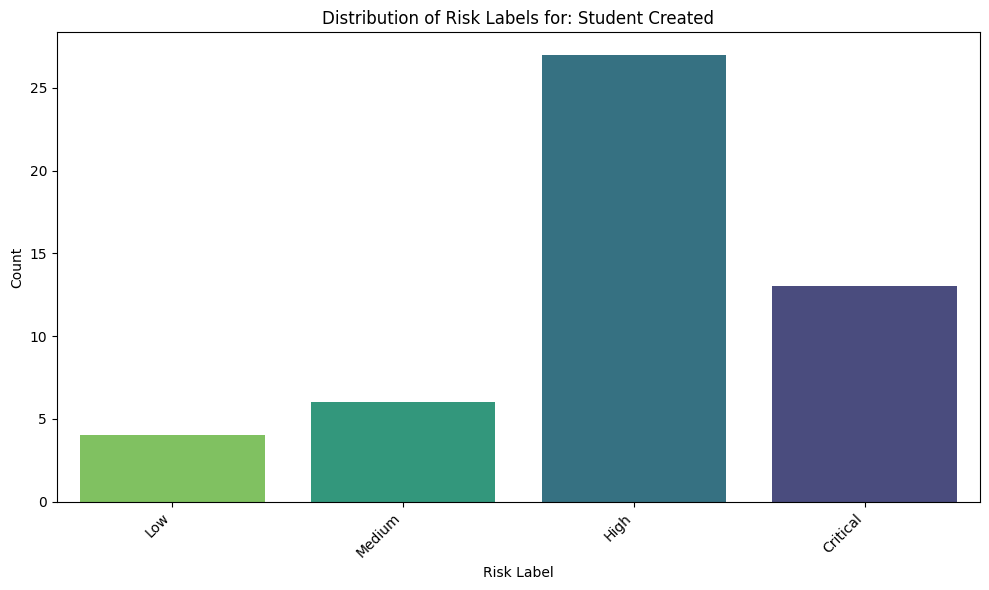

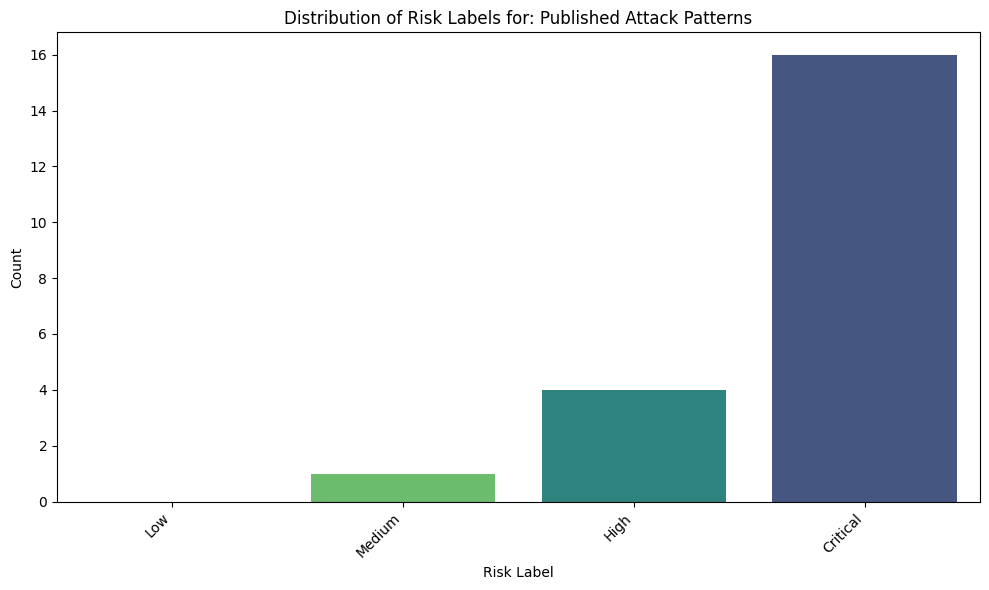

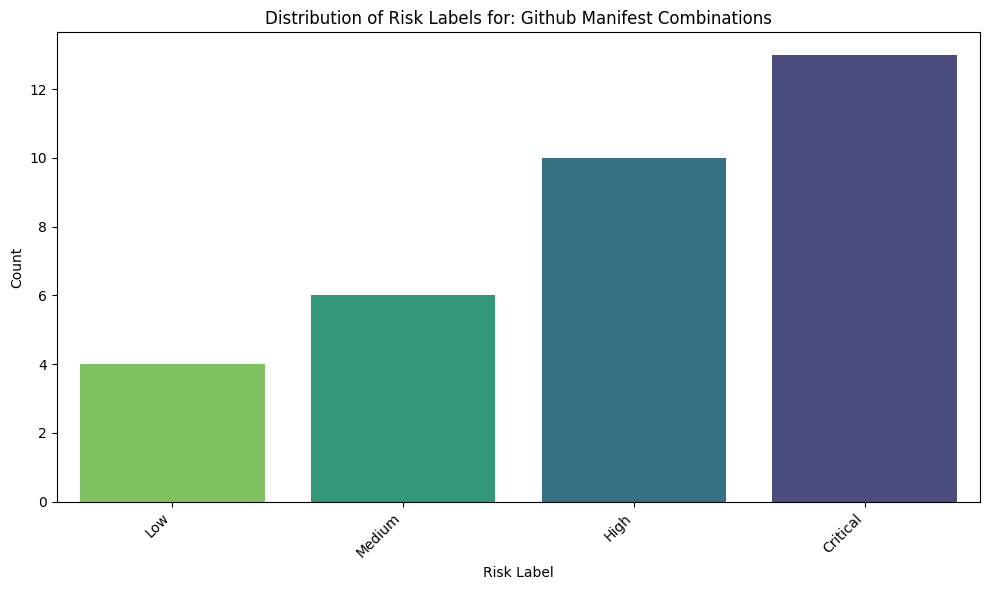

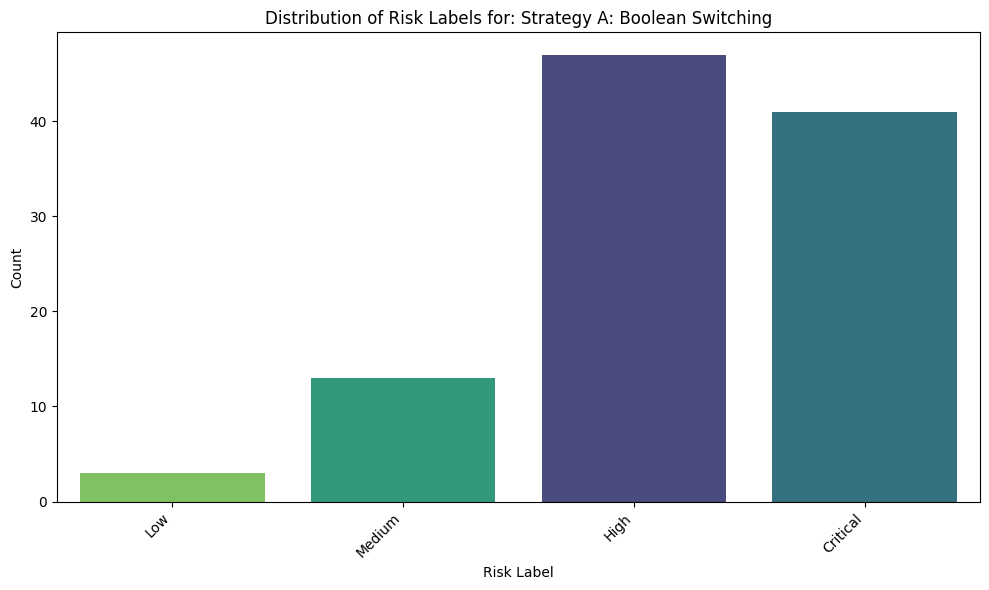

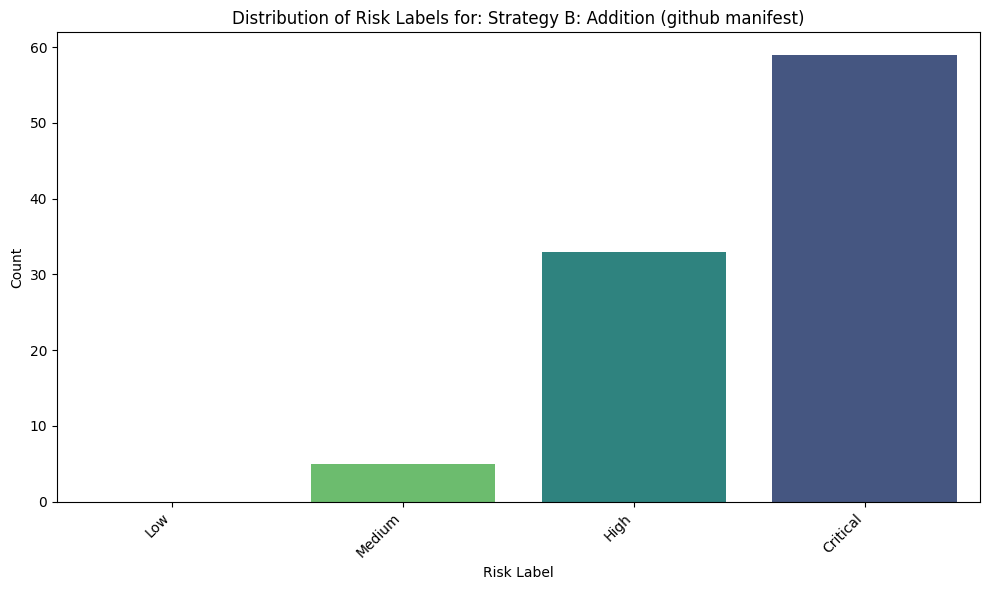

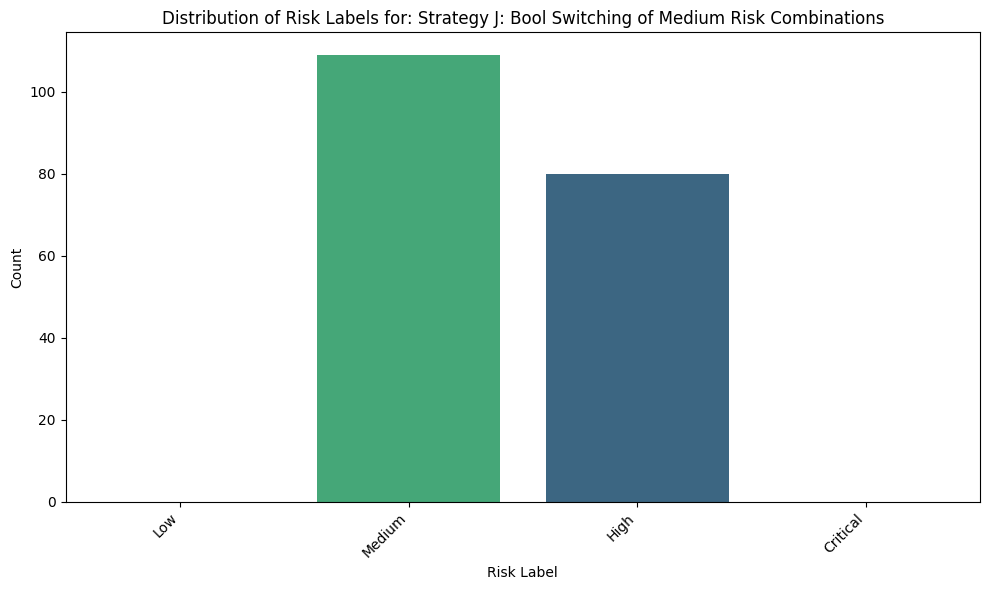

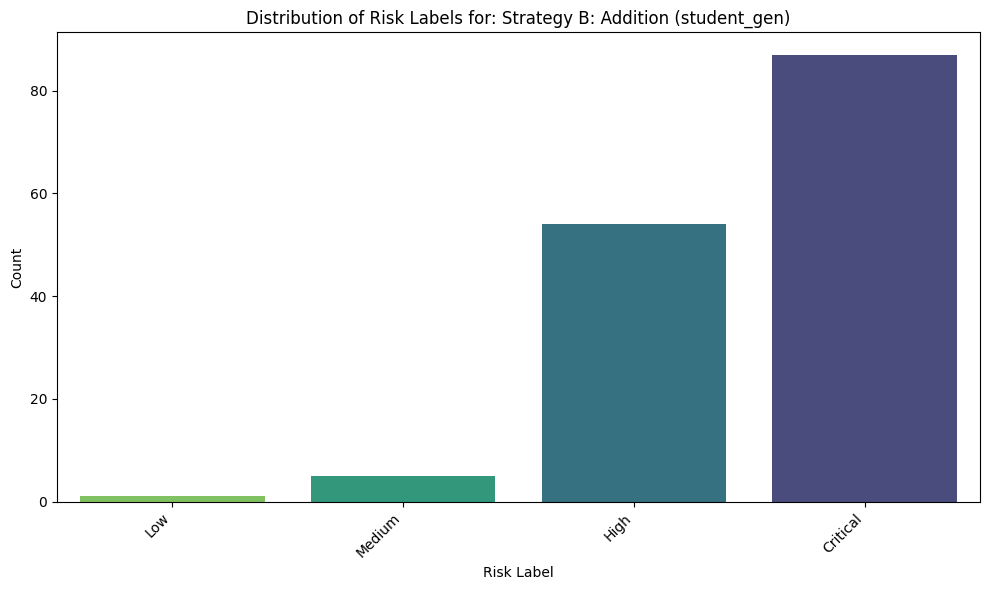

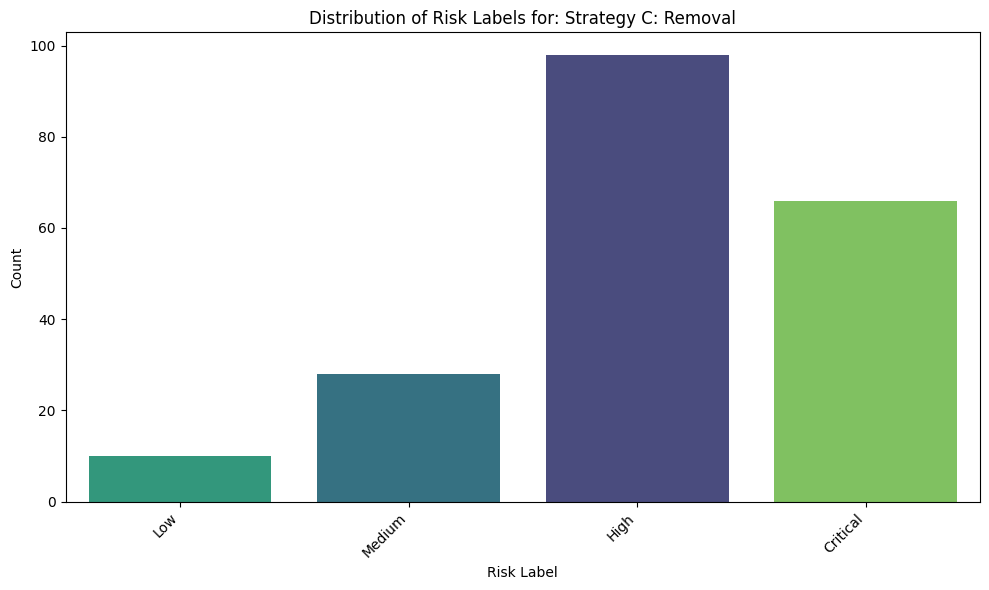

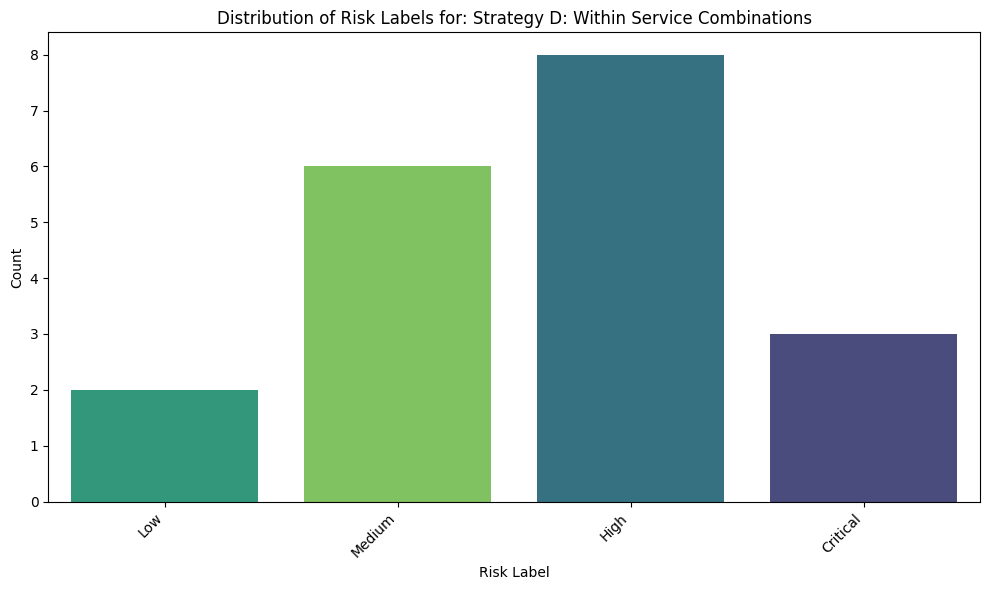

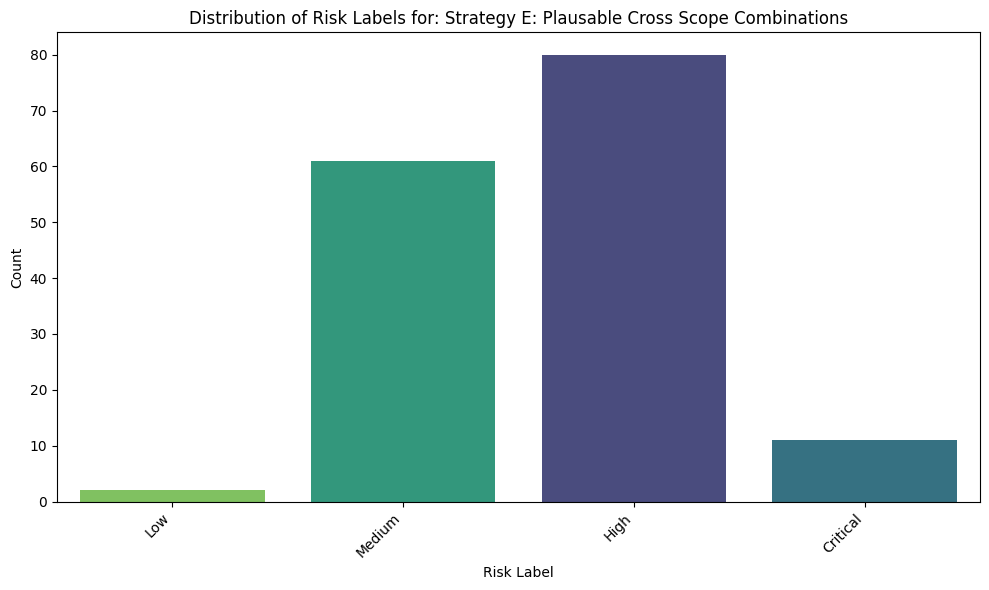

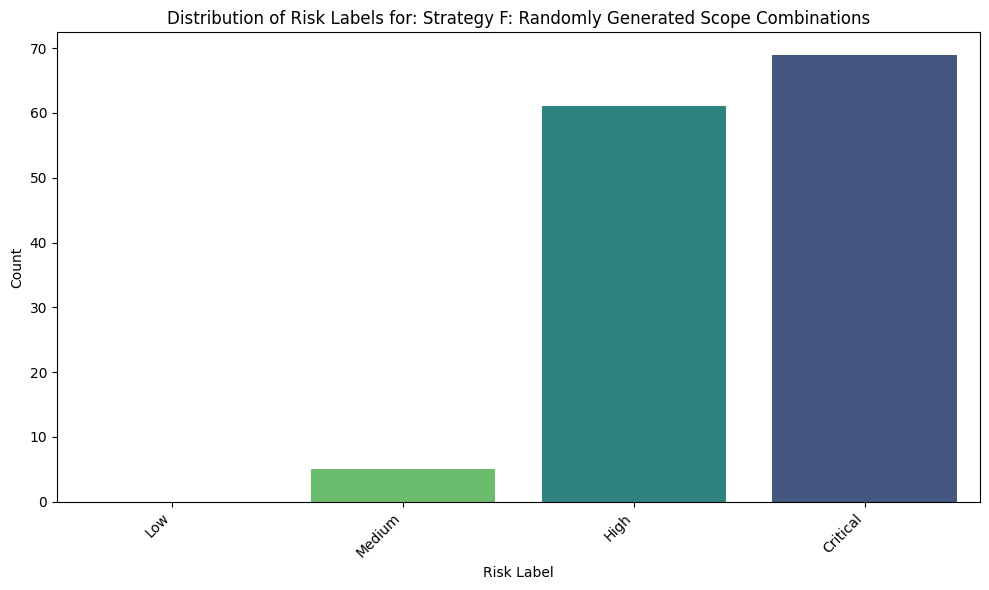

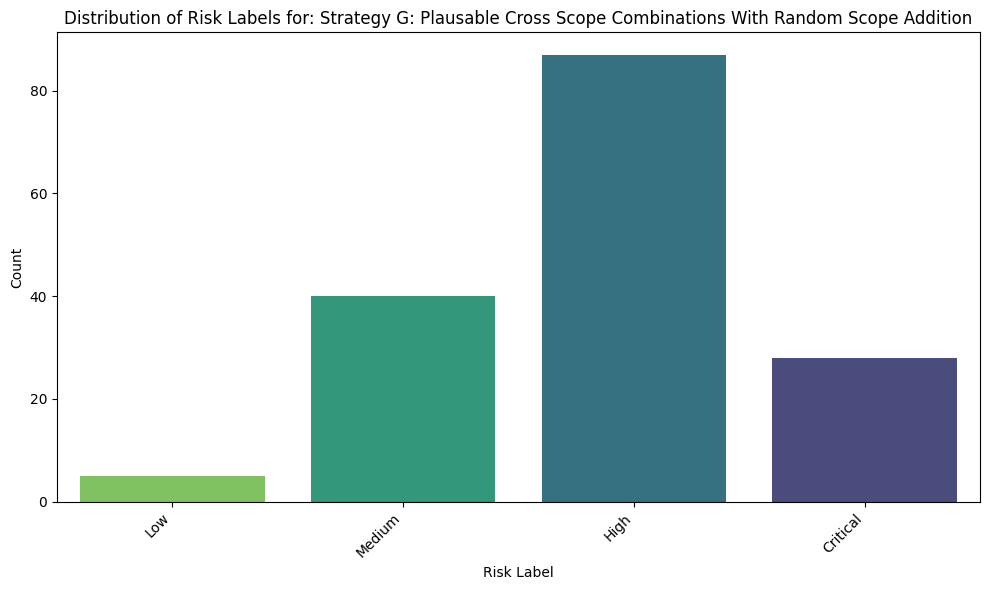

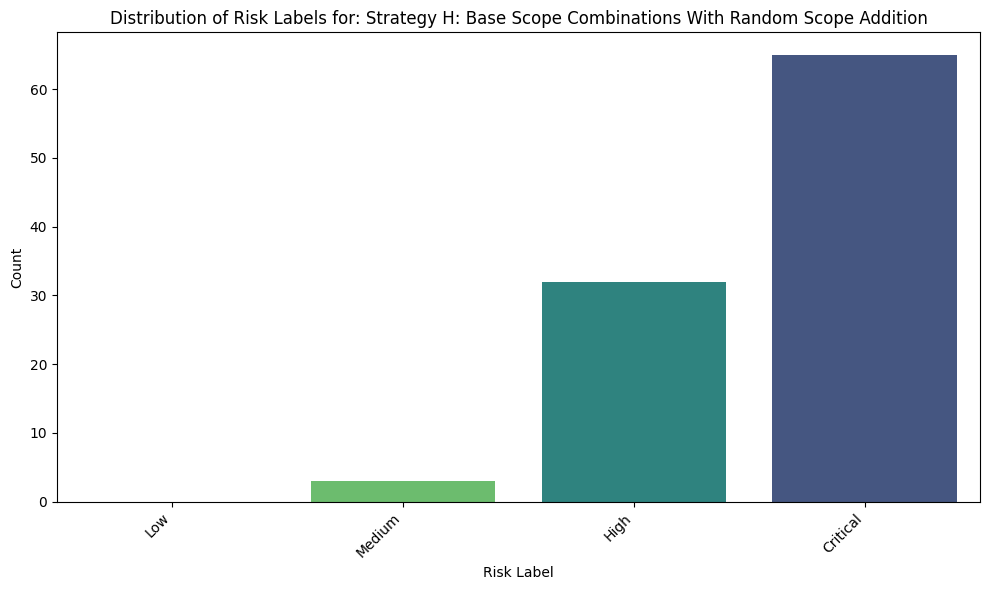

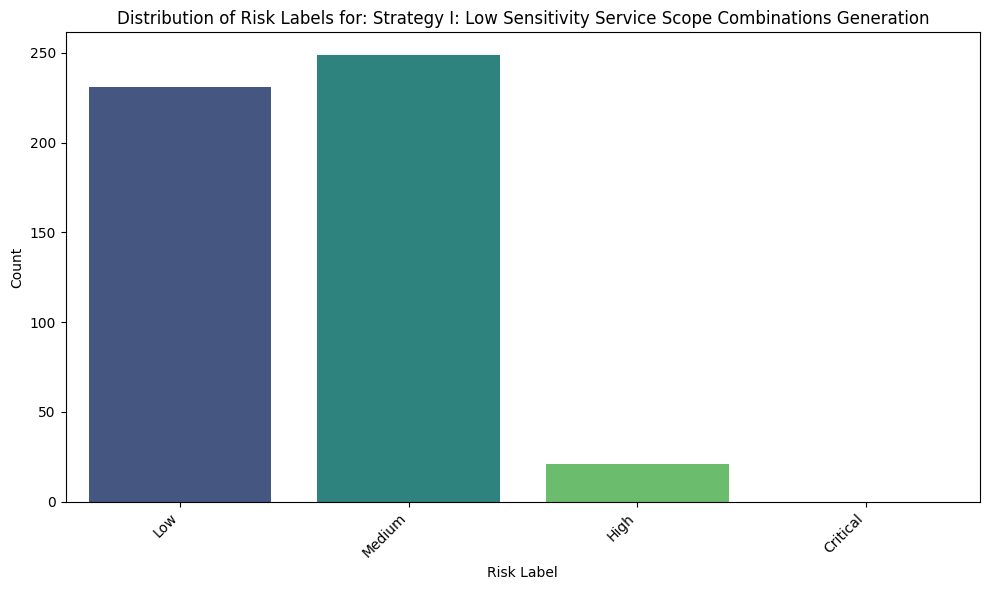

In [222]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique source categories
source_categories = df_new['source_category'].unique()

# Iterate through each source category and create a countplot
for category in source_categories:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_new[df_new['source_category'] == category], x='risk_label', order=['Low', 'Medium', 'High', 'Critical'], hue='risk_label', palette='viridis', legend=False)
    plt.title(f'Distribution of Risk Labels for: {category}')
    plt.xlabel('Risk Label')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

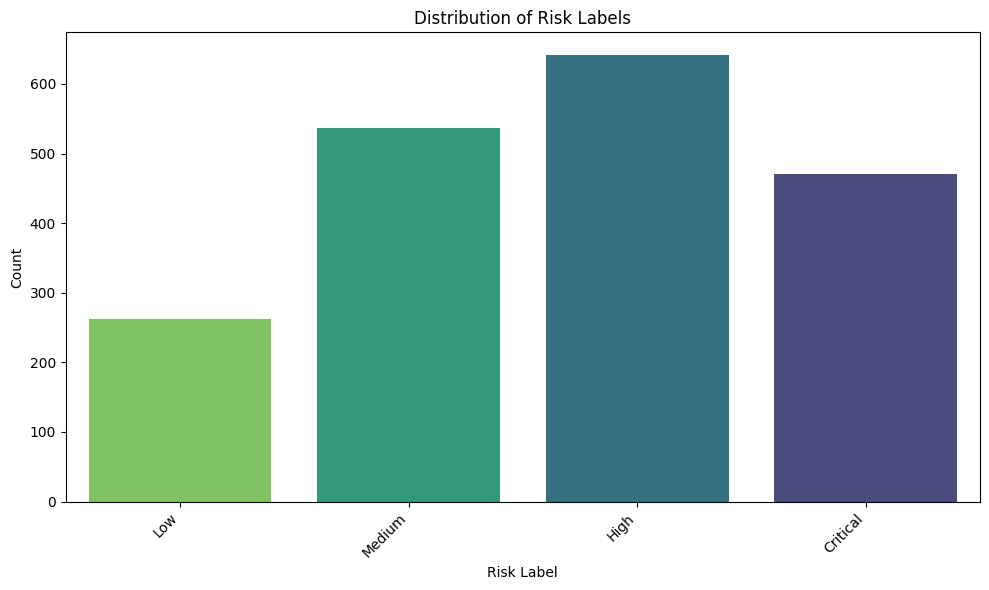

In [223]:

# Get unique source categories
source_categories = df_new['source_category'].unique()

# Iterate through each source category and create a countplot

plt.figure(figsize=(10, 6))
sns.countplot(data=df_new, x='risk_label', order=['Low', 'Medium', 'High', 'Critical'], hue='risk_label', palette='viridis', legend=False)
plt.title(f'Distribution of Risk Labels')
plt.xlabel('Risk Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()